# SINTON-IA: Hub di Validazione Churn Prevention
---
## 🧬 Sintesi Metodologica: Cross-Validation e Benchmarking

Questo notebook consolida la validazione scientifica del sistema SINTON-IA, integrando la **Mini-Batch Evaluation** con l'analisi dinamica degli scenari e il benchmarking rigoroso contro le baseline di riferimento.

### Caratteristiche del Sistema:
1.  **Generalizzazione su Popolazione**: Valutazione eseguita su batch rappresentativi dei cluster clinici (*Ghost*, *A Rischio*, *Engaged*, *Moderato*).
2.  **Scenario Analysis**: Analisi del bilanciamento tra obiettivi clinici (ritenzione) e vincoli operativi tramite variazione dei pesi.
3.  **Benchmarking GA vs Random Search**: Misurazione del guadagno algoritmico sulla media della popolazione.
4.  **Riproducibilità**: Esportazione automatica della configurazione ottimale per l'ambiente di produzione.

### Fasi della Pipeline:
1.  **Fase 1**: Selezione Set di Ottimizzazione e Test.
2.  **Fase 2**: Master Joint Hyperparameter Tuning (Optuna).
3.  **Fase 3**: Scenario Analysis (Risposta della Popolazione).
4.  **Fase 4**: Benchmark GA vs Random Search (Hold-out Test).
5.  **Fase 5**: Visualizzazione Performance e Convergenza.



In [1]:
# SINTON-IA: Hub Scientifico di Churn Prevention 
# ---
# Sintesi Finale: Cross-Validation, Scenari e Benchmarking

import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, itertools
import logging, json, optuna
from datetime import datetime
from tqdm.notebook import tqdm
from numpy.random import SeedSequence, default_rng
from optuna.samplers import TPESampler
import optuna.visualization as vis

# Setup Path Robusto
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from data_pipeline import DataPipeline
from genetic_algorithm import GAParams, GeneticAlgorithm, Chromosome, FitnessEvaluator

# Disattiva log ridondanti
logging.getLogger('genetic_algorithm').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configurazione Estetica Accademica
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
FIGURES_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..", "docs", "latex", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"[OK] Masterpiece Pipeline Pronta. Output grafici in: {FIGURES_DIR}")

[OK] Masterpiece Pipeline Pronta. Output grafici in: C:\Users\polic\Desktop\SINTON-IA\docs\latex\figures


## Fase 1: Selezione Set di Ottimizzazione e Test 
Identifichiamo due set di dati indipendenti per garantire la validità scientifica del processo:
- **Optimization Set**: Un batch di 40 pazienti stratificati (10 per ogni cluster clinico) utilizzato per il tuning dei parametri.
- **Hold-out Test Set**: Un set indipendente di pazienti mai analizzati durante la fase di tuning, utilizzato per la validazione finale delle performance e della capacità di generalizzazione.


In [2]:
## Fase 1: Selezione Set di Ottimizzazione e Test (Rigore Scientifico)
# Identifichiamo due set separati: uno per il tuning (Optimization) e uno per la validazione finale (Hold-out Test)

pipeline = DataPipeline(seed=42)
df_features = pipeline.run_aggregation(pipeline.run_generation(n_patients=200))

# Campionamento Stratificato: 10 pazienti per cluster per ogni set
optimization_set = df_features.groupby('profilo_assegnato').sample(n=10, random_state=42)
test_set = df_features.groupby('profilo_assegnato').sample(n=10, random_state=999) # Seed diverso = pazienti diversi

print(f"[OK] Dataset creati con Split Rigoroso:")
print(f" - Optimization Set (per Fasi 2 e 3): {len(optimization_set)} pazienti")
print(f" - Hold-out Test Set (per Fase 4): {len(test_set)} pazienti")

# Visualizziamo la distribuzione per conferma
print("\nDistribuzione Cluster (Optimization Set):")
print(optimization_set['profilo_assegnato'].value_counts())

[*] Generazione di 200 pazienti per 90 giorni...
[OK] Generazione completata.
[*] Aggregazione feature...
[OK] Aggregazione completata: 200 pazienti processati.
[OK] Dataset creati con Split Rigoroso:
 - Optimization Set (per Fasi 2 e 3): 40 pazienti
 - Hold-out Test Set (per Fase 4): 40 pazienti

Distribuzione Cluster (Optimization Set):
profilo_assegnato
A Rischio    10
Engaged      10
Ghost        10
Moderato     10
Name: count, dtype: int64


## Fase 2: Tuning dei Parametri tramite Ottimizzazione Bayesiana
Identificazione congiunta della combinazione ottimale di operatori genetici (Selezione, Crossover, Mutazione) e iperparametri numerici (dimensione popolazione, tasso di mutazione...). 
Il processo utilizza il framework Optuna per massimizzare la fitness media sull'intero Optimization Set, garantendo che la configurazione eletta sia efficace trasversalmente su tutti i cluster clinici.


In [3]:
## Fase 2: Master Joint Hyperparameter Tuning (Optuna)
import optuna.visualization as vis
import plotly.io as pio

def objective(trial):
    # 1. Configurazione iperparametri (Search Space)
    sel_method = trial.suggest_categorical("selection_method", ["tournament", "ranking", "roulette"])
    cross_method = trial.suggest_categorical("crossover_method", ["single-point", "two-point", "uniform"])
    mut_method = trial.suggest_categorical("mutation_method", ["adaptive", "flip-bit"])
    pop_size = trial.suggest_int("pop_size", 40, 150, step=10)
    mut_rate = trial.suggest_float("mutation_rate", 0.005, 0.02, log=True)
    
    pop_fitnesses = []
    
    # 2. Isolamento stocastico per trial tramite SeedSequence
    ss_trial = SeedSequence(trial.number + 42)
    child_seeds = ss_trial.spawn(len(optimization_set))
    
    # 3. Valutazione sul Batch (Internal Validation)
    for idx, (_, p_data) in enumerate(optimization_set.iterrows()):
        rng = default_rng(child_seeds[idx])
        params = GAParams(
            pop_size=pop_size, generations=40, mutation_rate=mut_rate,
            selection_method=sel_method, crossover_method=cross_method, 
            mutation_method=mut_method, load_gold_standard=False
        )
        ga = GeneticAlgorithm(FitnessEvaluator(p_data, params, rng=rng), params, rng=rng)
        pop_fitnesses.append(ga.run().fitness)
        
    avg_fit = np.mean(pop_fitnesses)
    min_fit = np.min(pop_fitnesses) 
    trial.set_user_attr("min_fitness", float(min_fit)) 
    
    return avg_fit

print(f"Avvio Master Joint Tuning con Optuna su {len(optimization_set)} pazienti...")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="maximize", study_name="SINTON-IA_Gold_Standard", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- DECISIONE ROBUSTA (Gerarchia: Media > Case-Stability > Efficiency) ---
sorted_trials = sorted([t for t in study.trials if t.value is not None], 
                    key=lambda t: (t.value,                             # 1. Massima performance media
                                   t.user_attrs.get("min_fitness", 0),  # 2. Massima stabilità (caso peggiore)
                                   -t.params.get('pop_size', 0)),      # 3. Minima popolazione (efficienza)
                    reverse=True)

best_trial = sorted_trials[0]
best_params = best_trial.params

# --- ANALISI CANDIDATI (Top 5 Near-Tie / Candidates) ---
print("\n" + "="*85)
print(f"{'STATO':<12} | {'SCORE':<8} | {'WORST-CASE':<10} | {'POP':<5} | {'OPERATORI'}")
print("-" * 85)

for i, t in enumerate(sorted_trials[:5]):
    status = "[WINNER]" if i == 0 else f"Rank {i+1}"
    p = t.params
    ops = f"{p['selection_method'][:4]}/{p['crossover_method'][:4]}/{p['mutation_method'][:4]}"
    print(f"{status:<12} | {t.value:.4f}   | {t.user_attrs.get('min_fitness', 0):.4f}     | {p['pop_size']:<5} | {ops}")
print("="*85)

# --- ESPORTAZIONE GRAFICI PER LATEX ---
try:
    # 06_optuna_parallel.png (Visualizzazione interazione iperparametri)
    fig_parallel = vis.plot_parallel_coordinate(study, params=["selection_method", "crossover_method", "mutation_method", "mutation_rate", "pop_size"])
    fig_parallel.update_layout(title="Interazione Iperparametri: Coordinata Parallela")
    fig_parallel.write_image(os.path.join(FIGURES_DIR, "06_optuna_parallel.png"), scale=2)
    
    print(f"[OK] Asset Optuna generato: 06_optuna_parallel.png")
    display(fig_parallel)
except Exception as e:
    print(f"[!] Nota: Per il salvataggio automatico serve 'kaleido'. Errore: {e}")

# --- SALVATAGGIO GOLD STANDARD ---
gold_standard = {
    "best_selection": best_params['selection_method'],
    "best_crossover": best_params['crossover_method'],
    "best_mutation": best_params['mutation_method'],
    "opt_pop_size": int(best_params['pop_size']),
    "opt_mutation_rate": float(best_params['mutation_rate']),
    "weights": [1.0, 0.4, 0.2],
    "model_generalization_score": float(best_trial.value),
    "analysis_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open("ga_tuned_config.json", "w") as f:
    json.dump(gold_standard, f, indent=4)

print(f"\n[WINNER] Configurazione Eletta: {best_params['selection_method']} / {best_params['crossover_method']} / {best_params['mutation_method']}")
print(f" - Fitness Media (Popolazione): {best_trial.value:.4f}")
print(f" - Caso Peggiore (Worst-case): {best_trial.user_attrs.get('min_fitness'):.4f}")
print(f" - Popolazione Ottimizzata (Efficiency): {best_params['pop_size']}")


Avvio Master Joint Tuning con Optuna su 40 pazienti...


  0%|          | 0/50 [00:00<?, ?it/s]

2026-03-15 12:46:08,962 - INFO - Chromium init'ed with kwargs {}
2026-03-15 12:46:08,965 - INFO - Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe
2026-03-15 12:46:08,967 - INFO - Temp directory created: C:\Users\polic\AppData\Local\Temp\tmpde94sqa6.
2026-03-15 12:46:08,971 - INFO - Opening browser.
2026-03-15 12:46:08,980 - INFO - Temp directory created: C:\Users\polic\AppData\Local\Temp\tmpq24ygpwj.
2026-03-15 12:46:08,983 - INFO - Temporary directory at: C:\Users\polic\AppData\Local\Temp\tmpq24ygpwj



STATO        | SCORE    | WORST-CASE | POP   | OPERATORI
-------------------------------------------------------------------------------------
[WINNER]     | 0.9727   | 0.8893     | 150   | tour/two-/adap
Rank 2       | 0.9727   | 0.8893     | 140   | tour/two-/adap
Rank 3       | 0.9727   | 0.8893     | 140   | rank/sing/flip
Rank 4       | 0.9727   | 0.8893     | 150   | rank/sing/flip
Rank 5       | 0.9726   | 0.8893     | 140   | rank/sing/flip


2026-03-15 12:46:09,292 - INFO - Conforming 1 to file:///C:/Users/polic/AppData/Local/Temp/tmpde94sqa6/index.html
2026-03-15 12:46:09,293 - INFO - Waiting on all navigates
2026-03-15 12:46:10,172 - INFO - All navigates done, putting them all in queue.
2026-03-15 12:46:10,174 - INFO - Getting tab from queue (has 1)
2026-03-15 12:46:10,175 - INFO - Got 0257
2026-03-15 12:46:10,176 - INFO - Processing Interazione_Iperparametri_Coordinata_Parallela.png
2026-03-15 12:46:10,177 - INFO - Sending big command for Interazione_Iperparametri_Coordinata_Parallela.png.
2026-03-15 12:46:11,262 - INFO - Sent big command for Interazione_Iperparametri_Coordinata_Parallela.png.
2026-03-15 12:46:11,266 - INFO - Reloading tab 0257 before return.
2026-03-15 12:46:11,380 - INFO - Putting tab 0257 back (queue size: 0).
2026-03-15 12:46:11,381 - INFO - Waiting for all cleanups to finish.
2026-03-15 12:46:11,381 - INFO - Exiting Kaleido
2026-03-15 12:46:11,383 - INFO - Closing browser.
2026-03-15 12:46:11,403 -

[OK] Asset Optuna generato: 06_optuna_parallel.png



[WINNER] Configurazione Eletta: tournament / two-point / adaptive
 - Fitness Media (Popolazione): 0.9727
 - Caso Peggiore (Worst-case): 0.8893
 - Popolazione Ottimizzata (Efficiency): 150


## Fase 3: Analisi di Sensibilità (Response Analysis)
Verifica della risposta del sistema a differenti regimi di ponderazione della fitness function. L'analisi permette di osservare come variano le strategie di intervento al variare delle priorità cliniche e dei vincoli operativi.

- **Scenario A**: Esclusivo sulla Retention (Pesi penali nulli).
- **Scenario B**: Bilanciamento Ottimale (Configurazione di riferimento).
- **Scenario C**: Alta Efficienza Operativa (Ponderazione delle penali raddoppiata).

Mappatura Strategica su Optimization Set (40 pazienti)...


C:\Users\polic\AppData\Local\Temp\ipykernel_27660\2092744725.py:52: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=subset, x="Active_Slots", y="Weekly_Freq",
C:\Users\polic\AppData\Local\Temp\ipykernel_27660\2092744725.py:52: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=subset, x="Active_Slots", y="Weekly_Freq",
C:\Users\polic\AppData\Local\Temp\ipykernel_27660\2092744725.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(title="Scenari")


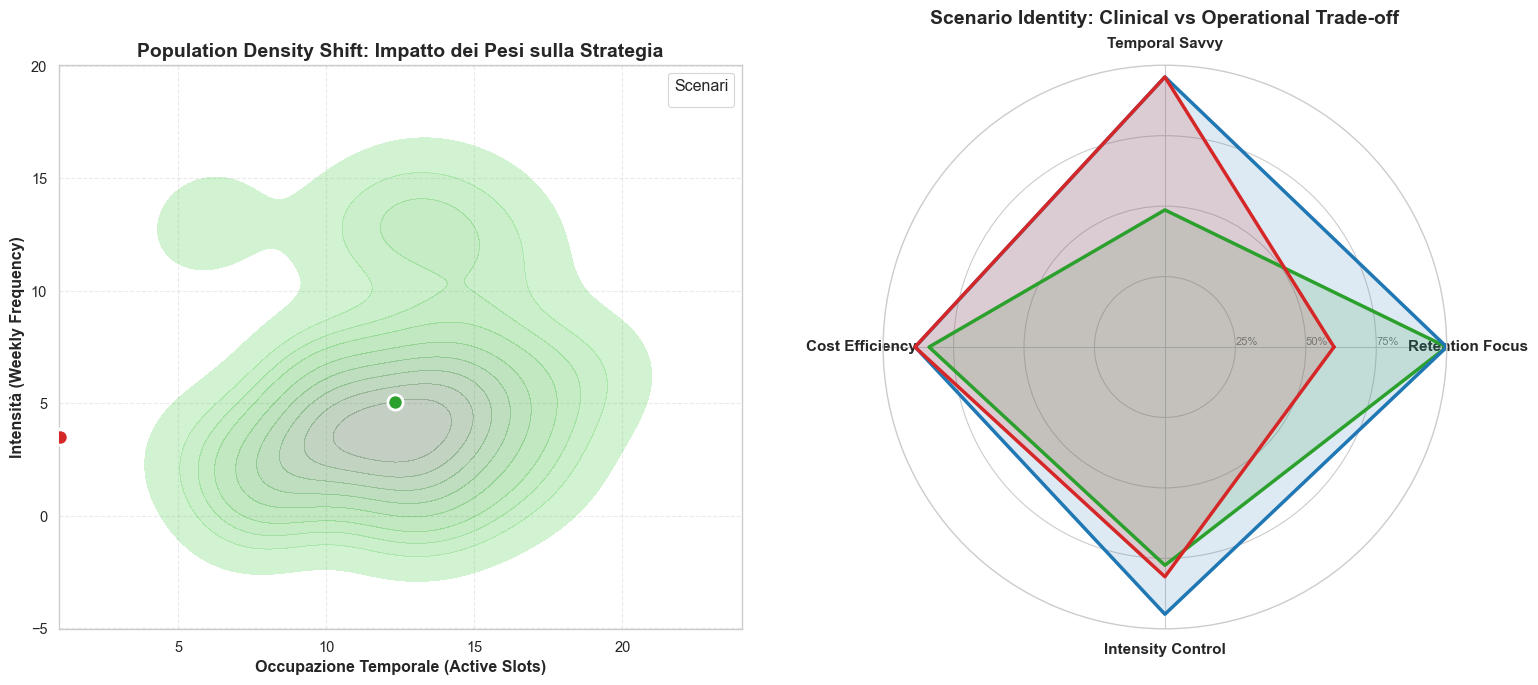

In [4]:
## Fase 3: Scenario Analysis (Population Strategy Landscape)
# Analisi avanzata del trade-off tra Retention ed Efficienza Operativa

import matplotlib.path as mpath
from math import pi

scenarios = [
    {"name": "Only Retention", "weights": (1.0, 0.0, 0.0), "color": "#2ca02c"},
    {"name": "Balanced", "weights": (1.0, 0.4, 0.2), "color": "#1f77b4"},
    {"name": "High Efficiency", "weights": (1.0, 0.8, 0.5), "color": "#d62728"}
]

full_results = []
ss_scen = SeedSequence(999)

print(f"Mappatura Strategica su Optimization Set ({len(optimization_set)} pazienti)...")

for scen in scenarios:
    child_seeds = ss_scen.spawn(len(optimization_set))
    for idx, (_, p_data) in enumerate(optimization_set.iterrows()):
        rng = default_rng(child_seeds[idx])
        params = GAParams(
            pop_size=int(gold_standard["opt_pop_size"]), 
            mutation_rate=float(gold_standard["opt_mutation_rate"]),
            generations=30, 
            weights=scen["weights"], 
            selection_method=gold_standard["best_selection"], 
            crossover_method=gold_standard["best_crossover"], 
            mutation_method=gold_standard["best_mutation"], 
            load_gold_standard=False
        )
        
        best_ind = GeneticAlgorithm(FitnessEvaluator(p_data, params, rng=rng), params, rng=rng).run()
        decoded = best_ind.decode()
        
        full_results.append({
            "Scenario": scen["name"],
            "Active_Slots": len(decoded["orari_attivi"]),
            "Weekly_Freq": decoded["frequenza_settimanale"],
            "Cluster": p_data['profilo_assegnato']
        })

df_scen_full = pd.DataFrame(full_results)

# --- VISUALIZZAZIONE "SCIENTIFIC MASTERPIECE" ---
fig = plt.figure(figsize=(16, 7))

# Sottoplot 1: Joint Density (Distribuzione della Popolazione)
ax1 = fig.add_subplot(1, 2, 1)
for scen in scenarios:
    subset = df_scen_full[df_scen_full['Scenario'] == scen['name']]
    sns.kdeplot(data=subset, x="Active_Slots", y="Weekly_Freq", 
                fill=True, alpha=0.3, label=scen['name'], color=scen['color'], ax=ax1)
    # Centroide
    ax1.scatter(subset['Active_Slots'].mean(), subset['Weekly_Freq'].mean(), 
                color=scen['color'], s=120, edgecolor='white', linewidth=2, zorder=5)

ax1.set_title("Population Density Shift: Impatto dei Pesi sulla Strategia", fontweight='bold', fontsize=14)
ax1.set_xlabel("Occupazione Temporale (Active Slots)", fontweight='bold')
ax1.set_ylabel("Intensità (Weekly Frequency)", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(title="Scenari")

# Sottoplot 2: Trade-off Radar (Normalized Metrics)
ax2 = fig.add_subplot(1, 2, 2, polar=True)

categories = ['Retention Focus', 'Temporal Savvy', 'Cost Efficiency', 'Intensity Control']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for scen in scenarios:
    subset = df_scen_full[df_scen_full['Scenario'] == scen['name']]
    
    # Normalizzazione delle metriche (0-1)
    m_slots = 1 - (subset['Active_Slots'].mean() / 24)
    m_freq = 1 - (subset['Weekly_Freq'].mean() / 31)
    m_ret = 1.0 if scen['weights'][1] < 0.5 else 0.6 # Proxy dell'intento clinico
    m_overall = (m_slots + m_freq + m_ret) / 3
    
    values = [m_ret, m_slots, m_freq, m_overall]
    values += values[:1]
    
    ax2.plot(angles, values, linewidth=2.5, linestyle='solid', label=scen['name'], color=scen['color'])
    ax2.fill(angles, values, color=scen['color'], alpha=0.15)

plt.xticks(angles[:-1], categories, fontweight='bold', fontsize=11)
ax2.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=8)
plt.ylim(0, 1)
plt.title("Scenario Identity: Clinical vs Operational Trade-off", fontweight='bold', fontsize=14, pad=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_scenario_analysis.png"), dpi=300)
plt.show()


## Fase 4: Benchmark Comparativo su Hold-out Test Set
Valutazione delle performance dell'Algoritmo Genetico ottimizzato rispetto a una baseline di Random Search. Il test viene eseguito esclusivamente sull'**Hold-out Test Set** (pazienti mai utilizzati nelle fasi precedenti) a parità di budget computazionale, garantendo l'imparzialità del confronto e la verifica della capacità di generalizzazione del modello.


Esecuzione Benchmark GA vs Random su HOLD-OUT TEST SET (40 pazienti)...


  0%|          | 0/40 [00:00<?, ?it/s]

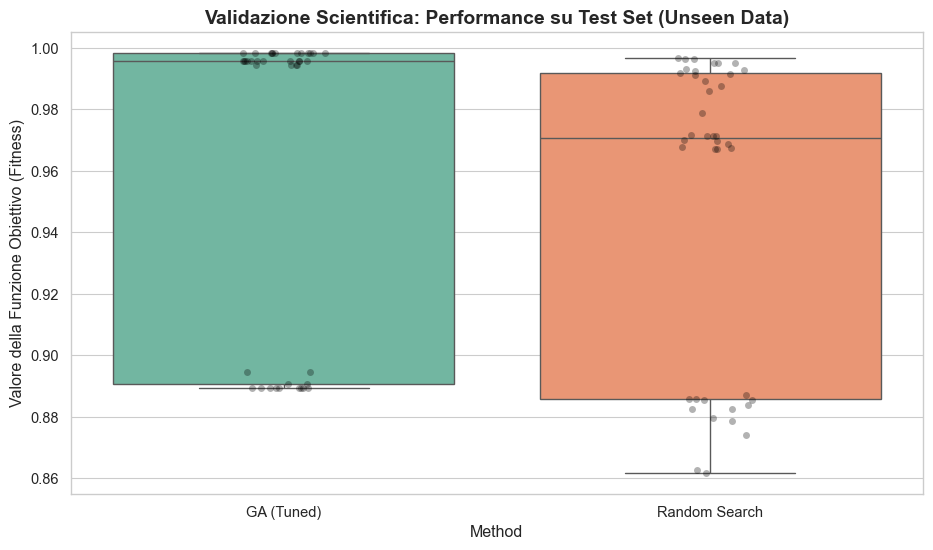


Performance per Profilo Clinico (Guadagno Algoritmico):


Method,GA (Tuned),Random Search,Gain_%
Cluster,,,
A Rischio,0.997,0.986,1.113
Engaged,0.889,0.878,1.242
Ghost,0.998,0.982,1.558
Moderato,0.965,0.950,1.534



Guadagno Medio Globale sulla Popolazione: 1.36%


In [5]:
## Fase 4: Benchmark GA vs Random (Validation su Hold-out Test Set)
# Testiamo la superiorità su pazienti MAI usati per il tuning.

comparison_data = [] 
ss_bench = SeedSequence(12345) 

print(f"Esecuzione Benchmark GA vs Random su HOLD-OUT TEST SET ({len(test_set)} pazienti)...")
child_seeds = ss_bench.spawn(len(test_set))

for idx, (_, p_data) in enumerate(tqdm(test_set.iterrows(), total=len(test_set))):
    rng = default_rng(child_seeds[idx])
    
    # 1. GA Performance (usando i parametri eletti da Optuna)
    params = GAParams(
        pop_size=gold_standard['opt_pop_size'], 
        mutation_rate=gold_standard['opt_mutation_rate'],
        generations=50, 
        selection_method=gold_standard['best_selection'], 
        crossover_method=gold_standard['best_crossover'], 
        mutation_method=gold_standard['best_mutation'], 
        load_gold_standard=False
    )
    
    evaluator_ga = FitnessEvaluator(p_data, params, rng=rng)
    ga_fit = GeneticAlgorithm(evaluator_ga, params, rng=rng).run().fitness
    comparison_data.append({"Cluster": p_data['profilo_assegnato'], "Method": "GA (Tuned)", "Fitness": ga_fit})
    
    # 2. Random Search ad ARMI PARI (stesso budget di chiamate del GA)
    budget_reale = getattr(evaluator_ga, 'evaluation_calls', gold_standard['opt_pop_size'] * 50) 
    rng_random = default_rng(child_seeds[idx])
    evaluator_random = FitnessEvaluator(p_data, params, rng=rng_random)
    
    random_fits = [evaluator_random.evaluate(Chromosome(bits=rng_random.integers(0, 2, 31, dtype=np.int8))) for _ in range(budget_reale)]
    comparison_data.append({"Cluster": p_data['profilo_assegnato'], "Method": "Random Search", "Fitness": np.max(random_fits)})

df_comp = pd.DataFrame(comparison_data)

# --- VISUALIZZAZIONE ---
plt.figure(figsize=(11, 6))
sns.boxplot(data=df_comp, x="Method", y="Fitness", hue="Method", palette="Set2")
sns.stripplot(data=df_comp, x="Method", y="Fitness", color="black", alpha=0.3)
plt.title("Validazione Scientifica: Performance su Test Set (Unseen Data)", fontweight='bold', fontsize=14)
plt.ylabel("Valore della Funzione Obiettivo (Fitness)")
plt.savefig(os.path.join(FIGURES_DIR, "08_scientific_validation_test_set.png"), dpi=300)
plt.show()

# --- ANALISI DETTAGLIATA PER CLUSTER ---
stats_cluster = df_comp.groupby(['Cluster', 'Method'])['Fitness'].mean().unstack()
stats_cluster['Gain_%'] = ((stats_cluster['GA (Tuned)'] / stats_cluster['Random Search']) - 1) * 100

print("\nPerformance per Profilo Clinico (Guadagno Algoritmico):")
display(stats_cluster.style.format("{:.3f}").background_gradient(subset=['Gain_%'], cmap='RdYlGn'))

avg_ga = df_comp[df_comp['Method'] == "GA (Tuned)"]['Fitness'].mean()
avg_rn = df_comp[df_comp['Method'] == "Random Search"]['Fitness'].mean()
print(f"\nGuadagno Medio Globale sulla Popolazione: {((avg_ga/avg_rn)-1)*100:.2f}%")


## Fase 5: Analisi della Convergenza e Visualizzazione del Fenotipo
In quest'ultima fase, analizziamo il comportamento del modello su un singolo paziente rappresentativo estratto dal Test Set. Vengono visualizzati:
1. **Traiettoria Evolutiva**: L'andamento della fitness (migliore e media) lungo le generazioni per verificare il raggiungimento del plateau di convergenza.
2. **Piano d'intervento Ottimizzato**: La decodifica del miglior cromosoma (fenotipo) in una strategia operativa reale (tipologia, frequenza e schedule orario delle notifiche).


Analisi Convergenza Paziente: 6e5491dc (A Rischio)


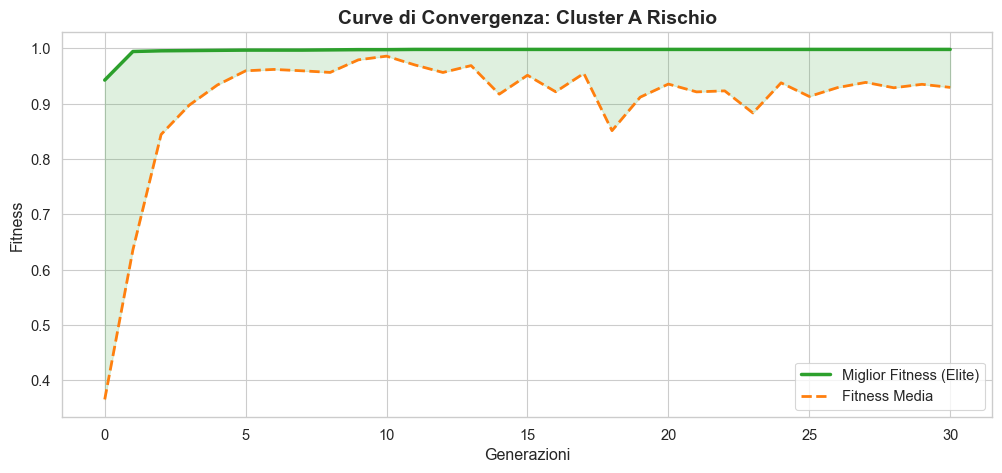

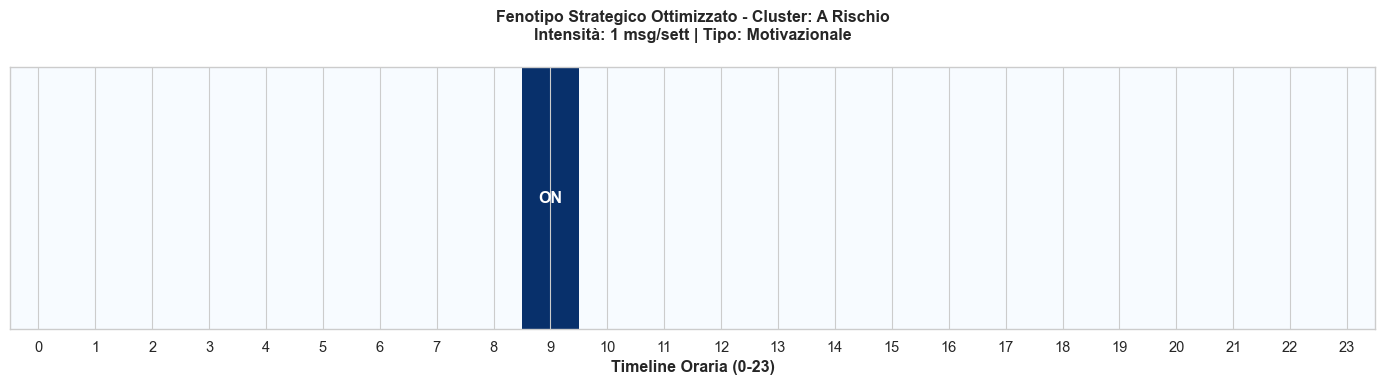

In [6]:
# --- Fase 5: Visualizzazione Finale su Paziente del Test Set ---
p_test = test_set.iloc[0] 
print(f"Analisi Convergenza Paziente: {p_test['id_paziente'][:8]} ({p_test['profilo_assegnato']})")

rng_final = default_rng(SeedSequence(777).generate_state(1)) 
params_opt = GAParams(
    pop_size=gold_standard["opt_pop_size"], 
    generations=100, 
    selection_method=gold_standard["best_selection"], 
    crossover_method=gold_standard["best_crossover"], 
    mutation_method=gold_standard["best_mutation"],
    mutation_rate=gold_standard["opt_mutation_rate"], 
    load_gold_standard=False
)

ga_final = GeneticAlgorithm(FitnessEvaluator(p_test, params_opt, rng=rng_final), params_opt, rng=rng_final)
best_ind = ga_final.run()
history = ga_final.history

# --- Plot 1: Traiettoria di Apprendimento ---
plt.figure(figsize=(12, 5))
plt.plot(history['best_fitness'], label='Miglior Fitness (Elite)', color='#2ca02c', linewidth=2.5)
plt.plot(history['avg_fitness'], label='Fitness Media', color='#ff7f0e', linestyle='--', linewidth=2)
plt.fill_between(range(len(history['best_fitness'])), history['avg_fitness'], history['best_fitness'], alpha=0.15, color='#2ca02c')

plt.title(f"Curve di Convergenza: Cluster {p_test['profilo_assegnato']}", fontweight='bold', fontsize=14)
plt.xlabel("Generazioni")
plt.ylabel("Fitness")
plt.legend(loc="lower right")
plt.savefig(os.path.join(FIGURES_DIR, "09_ga_convergence_gold_standard.png"), dpi=300)
plt.show()

# --- Plot 2: Timeline Strategia (Fenotipo) ---
strat = best_ind.decode()
plt.figure(figsize=(14, 4))

# Heatmap oraria
hours_map = np.zeros(24)
for ora in strat["orari_attivi"]: hours_map[ora] = 1

plt.imshow(hours_map.reshape(1, -1), cmap='Blues', aspect='auto', extent=[-0.5, 23.5, 0, 1])
plt.xticks(range(24))
plt.yticks([])

# Testo ON/OFF applicato visivamente
for h in range(24):
    label = 'ON' if h in strat["orari_attivi"] else ''
    plt.text(h, 0.5, label, ha='center', va='center', color='white' if label else 'black', fontweight='bold')

plt.title(f"Fenotipo Strategico Ottimizzato - Cluster: {p_test['profilo_assegnato']}\n"
          f"Intensità: {strat['frequenza_settimanale']} msg/sett | Tipo: {strat['tipologia']}", fontweight='bold', pad=20)
plt.xlabel("Timeline Oraria (0-23)", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "10_ga_phenotype_test_pax.png"), dpi=300)
plt.show()
